In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor,
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load Dataset


In [137]:
df = pd.read_csv("StudentsPerformance.csv")
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


# Check Null Values


In [138]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

# Check Values inside the columns


In [139]:
df["gender"].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

In [140]:
df["race/ethnicity"].value_counts()

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

In [141]:
df["parental level of education"].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [142]:
df["lunch"].value_counts()

lunch
standard        645
free/reduced    355
Name: count, dtype: int64

In [143]:
df["lunch"].unique()

array(['standard', 'free/reduced'], dtype=object)

# Data Analysis


In [144]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [145]:
df.shape

(1000, 8)

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [147]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Check and Drop Duplicate Values


In [148]:
print("Total Duplicate Data : ", df.duplicated().sum())

Total Duplicate Data :  0


In [149]:
df.drop_duplicates(inplace=True)

In [150]:
print("After Droping Total Duplicate Data : ", df.duplicated().sum())

After Droping Total Duplicate Data :  0


# Fill Null Values


In [151]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["race/ethnicity"] = df["race/ethnicity"].fillna(df["race/ethnicity"].mode()[0])
df["parental level of education"] = df["parental level of education"].fillna(
    df["parental level of education"].mode()[0]
)
df["lunch"] = df["lunch"].fillna(df["lunch"].mode()[0])
df["test preparation course"] = df["test preparation course"].fillna(
    df["test preparation course"].mode()[0]
)
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [152]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [153]:
df["math score"] = df["math score"].fillna(df["math score"].mean())
df["reading score"] = df["reading score"].fillna(df["reading score"].mean())
df["writing score"] = df["writing score"].fillna(df["writing score"].mean())

In [154]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

# Creating Target Column


In [155]:
df["average score"] = (df["math score"] + df["reading score"] + df["writing score"]) / 3

In [156]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,65.000000
998,female,group D,some college,standard,completed,68,78,77,74.333333


# Detecting Outliers


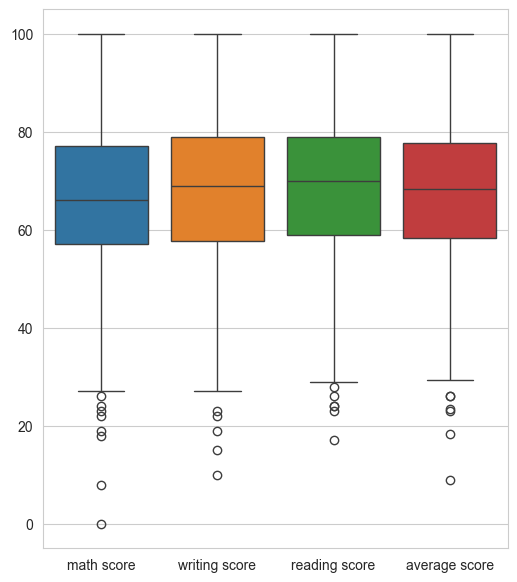

In [157]:
plt.figure(figsize=(6, 7))
sns.boxplot(data=df[["math score", "writing score", "reading score", "average score"]])
plt.show()

# Handaling Outliers


In [158]:
cols = ["math score", "reading score", "writing score", "average score"]

for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [159]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,65.000000
998,female,group D,some college,standard,completed,68,78,77,74.333333


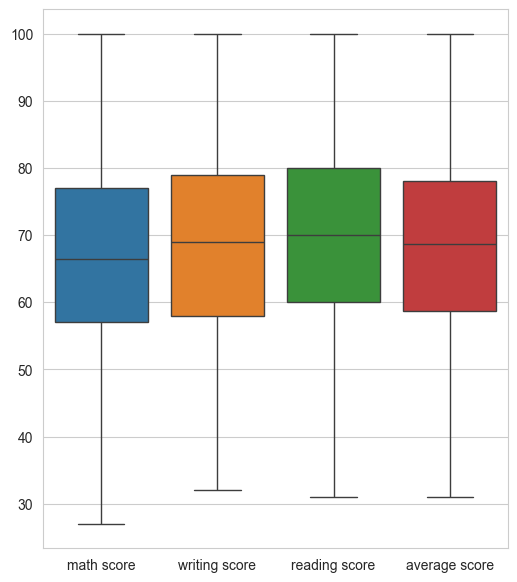

In [160]:
plt.figure(figsize=(6, 7))
sns.boxplot(data=df[["math score", "writing score", "reading score", "average score"]])
plt.show()

In [161]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,65.000000
998,female,group D,some college,standard,completed,68,78,77,74.333333


# Students Average Score Based on Gender


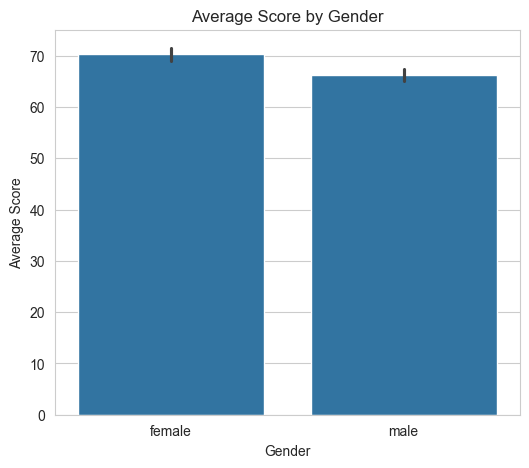

In [162]:
plt.figure(figsize=(6, 5))
sns.barplot(x="gender", y="average score", data=df)

plt.title("Average Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")

plt.show()

In [163]:
df.shape

(986, 9)

In [164]:
df.describe()

,math score,reading score,writing score,average score
count,986.000000,986.000000,986.000000,986.000000
mean,66.694726,69.723124,68.648073,68.355308
std,14.340780,13.910716,14.427092,13.459114
min,27.000000,31.000000,32.000000,31.000000
25%,57.000000,60.000000,58.000000,58.666667
50%,66.500000,70.000000,69.000000,68.666667
75%,77.000000,80.000000,79.000000,78.000000
max,100.000000,100.000000,100.000000,100.000000


# Scatter Plot


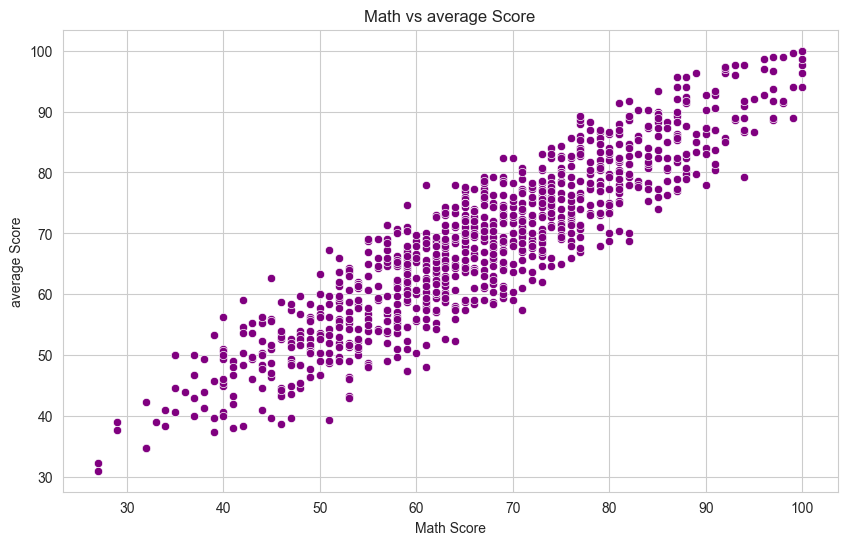

In [165]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x="math score", y="average score", data=df, color="purple")

plt.title("Math vs average Score")
plt.xlabel("Math Score")
plt.ylabel("average Score")

plt.show()

# Pair Plot


<Figure size 1000x600 with 0 Axes>

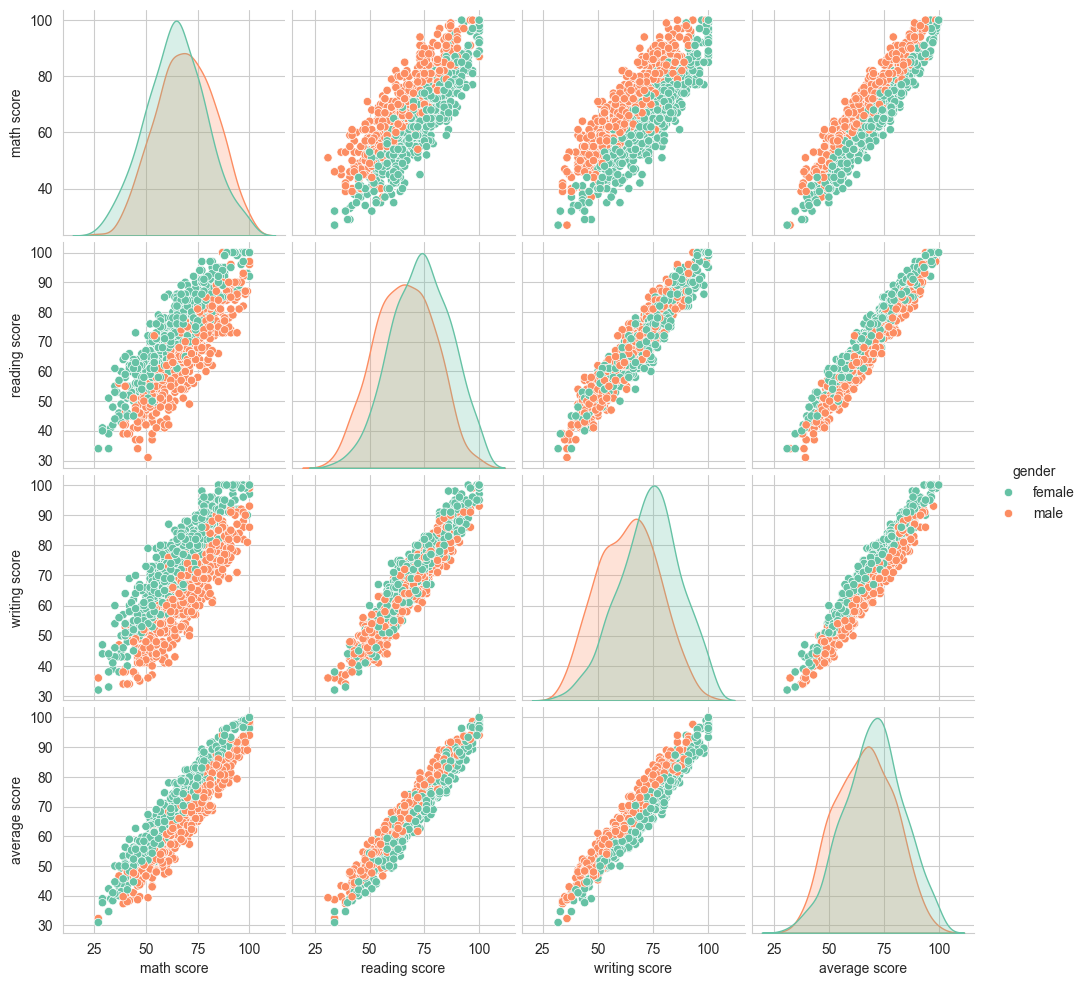

In [166]:
plt.figure(figsize=(10, 6))
sns.pairplot(df, hue="gender", palette="Set2", diag_kind="kde")
plt.show()

# Encoding Data


In [167]:
education_map = {
    "some high school": "HS",
    "high school": "HS",
    "some college": "Bachelor",
    "associate's degree": "Bachelor",
    "bachelor's degree": "Bachelor",
    "master's degree": "Master",
}
df["parental level of education"] = df["parental level of education"].map(education_map)

In [168]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
0,female,group B,Bachelor,standard,none,72,72,74,72.666667
1,female,group C,Bachelor,standard,completed,69,90,88,82.333333
2,female,group B,Master,standard,none,90,95,93,92.666667
3,male,group A,Bachelor,free/reduced,none,47,57,44,49.333333
4,male,group C,Bachelor,standard,none,76,78,75,76.333333
...,...,...,...,...,...,...,...,...,...
995,female,group E,Master,standard,completed,88,99,95,94.000000
996,male,group C,HS,free/reduced,none,62,55,55,57.333333
997,female,group C,HS,free/reduced,completed,59,71,65,65.000000
998,female,group D,Bachelor,standard,completed,68,78,77,74.333333


In [169]:
df = pd.get_dummies(
    df,
    columns=[
        "gender",
        "race/ethnicity",
        "parental level of education",
        "lunch",
        "test preparation course",
    ],
    drop_first=True,
)

In [170]:
df

,math score,reading score,writing score,average score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_HS,parental level of education_Master,lunch_standard,test preparation course_none
0,72,72,74,72.666667,False,True,False,False,False,False,False,True,True
1,69,90,88,82.333333,False,False,True,False,False,False,False,True,False
2,90,95,93,92.666667,False,True,False,False,False,False,True,True,True
3,47,57,44,49.333333,True,False,False,False,False,False,False,False,True
4,76,78,75,76.333333,True,False,True,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,88,99,95,94.000000,False,False,False,False,True,False,True,True,False
996,62,55,55,57.333333,True,False,True,False,False,True,False,False,True
997,59,71,65,65.000000,False,False,True,False,False,True,False,False,False
998,68,78,77,74.333333,False,False,False,True,False,False,False,True,False


# Correlation Matrix


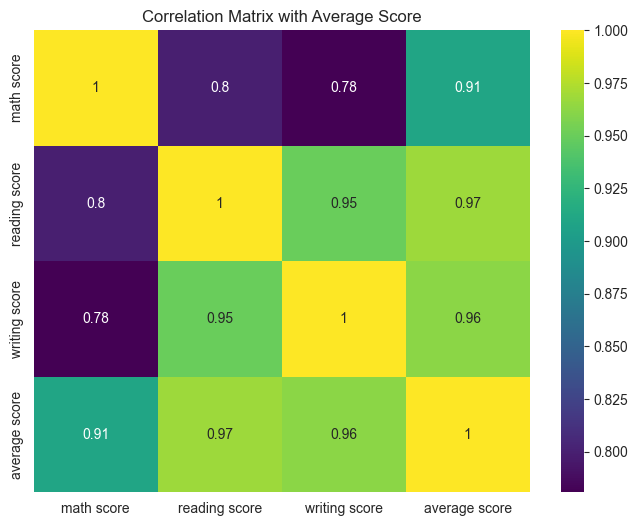

In [171]:
corr = df[["math score", "reading score", "writing score", "average score"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="viridis")
plt.title("Correlation Matrix with Average Score")
plt.show()

# Spliting Features(X) and Target(Y) columns


In [172]:
X = df.drop("average score", axis=1)
y = df["average score"]

In [173]:
X

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_HS,parental level of education_Master,lunch_standard,test preparation course_none
0,72,72,74,False,True,False,False,False,False,False,True,True
1,69,90,88,False,False,True,False,False,False,False,True,False
2,90,95,93,False,True,False,False,False,False,True,True,True
3,47,57,44,True,False,False,False,False,False,False,False,True
4,76,78,75,True,False,True,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
995,88,99,95,False,False,False,False,True,False,True,True,False
996,62,55,55,True,False,True,False,False,True,False,False,True
997,59,71,65,False,False,True,False,False,True,False,False,False
998,68,78,77,False,False,False,True,False,False,False,True,False


In [174]:
y

0      72.666667
1      82.333333
2      92.666667
3      49.333333
4      76.333333
         ...    
995    94.000000
996    57.333333
997    65.000000
998    74.333333
999    83.000000
Name: average score, Length: 986, dtype: float64

# Spliting Train and Test Data


In [175]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [176]:
X_train.shape

(788, 12)

In [177]:
X_test.shape

(198, 12)

In [178]:
y_train.shape

(788,)

In [179]:
y_test.shape

(198,)

# Standardize Data


In [180]:
st_x = StandardScaler()
X_train_scale = st_x.fit_transform(X_train)
X_test_scale = st_x.transform(X_test)

# Train Linear Model


In [181]:
lr = LinearRegression(fit_intercept=True, positive=True)
lr.fit(X_train_scale, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",True


# Linear Model Equation


In [182]:
intercept = lr.intercept_
coefficients = lr.coef_
print("Intercept : ", intercept)
print("Coefficients : ", coefficients)
equation = f"y = {intercept:.2f}"

for i, coef in enumerate(coefficients):
    equation += f" + ({coef:.2f} * x{i+1})"

print("Linear Regression Equation:")
print(equation)

Intercept :  68.49323181049068
Coefficients :  [4.74186932e+00 4.67048954e+00 4.78291864e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 6.60472953e-17 6.93287870e-17
 5.99805419e-17 0.00000000e+00 1.60346272e-17 0.00000000e+00]
Linear Regression Equation:
y = 68.49 + (4.74 * x1) + (4.67 * x2) + (4.78 * x3) + (0.00 * x4) + (0.00 * x5) + (0.00 * x6) + (0.00 * x7) + (0.00 * x8) + (0.00 * x9) + (0.00 * x10) + (0.00 * x11) + (0.00 * x12)


# Prediction


In [204]:
y_pred_lr = lr.predict(X_test_scale)
y_pred_lr[:20]

array([ 94.        , 100.        ,  50.        ,  77.33333333,
        49.        ,  56.33333333,  97.        ,  77.33333333,
        83.        ,  59.33333333,  60.66666667,  87.66666667,
        65.        ,  70.33333333,  84.        ,  58.33333333,
        41.33333333,  73.66666667,  72.66666667,  88.        ])

# Compare Actual and Predicted Value


In [184]:
actual_predicted = pd.DataFrame(
    {"Actual value": y_test.values, "Predicted value": y_pred_lr}
)
actual_predicted.head(15)

,Actual value,Predicted value
0,94.000000,94.000000
1,100.000000,100.000000
2,50.000000,50.000000
3,77.333333,77.333333
4,49.000000,49.000000
5,56.333333,56.333333
6,97.000000,97.000000
7,77.333333,77.333333
8,83.000000,83.000000
9,59.333333,59.333333


# Evalution of Linear Model


In [185]:
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MSE:", mse_lr)
print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE score:", rmse_lr)
print("Linear Regression R2 score:", r2_lr)

Linear Regression MSE: 1.1219355096476613e-28
Linear Regression MAE: 9.043271182401275e-15
Linear Regression RMSE score: 1.0592145720521698e-14
Linear Regression R2 score: 1.0


# Actual vs Predicted plot


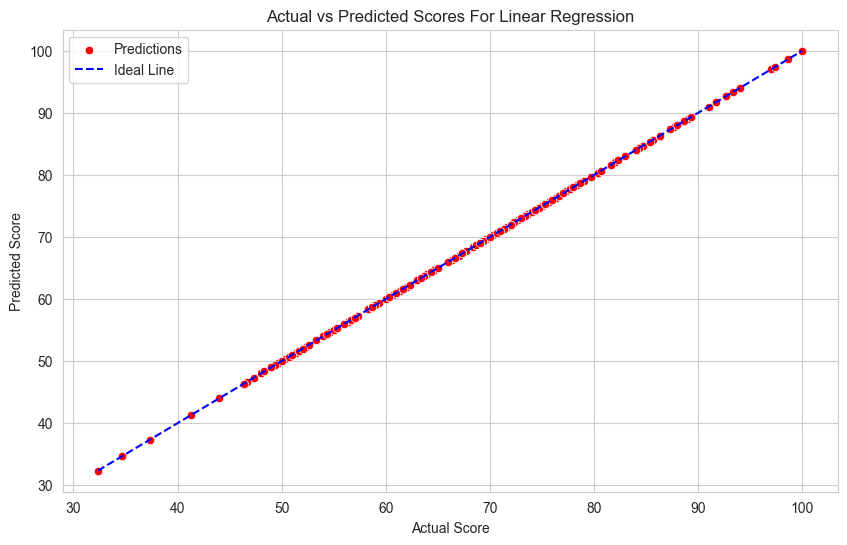

In [186]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=y_pred_lr, color="red", label="Predictions")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="blue",
    linestyle="--",
    label="Ideal Line",
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores For Linear Regression")
plt.legend()


sns.set_style("whitegrid")

plt.show()

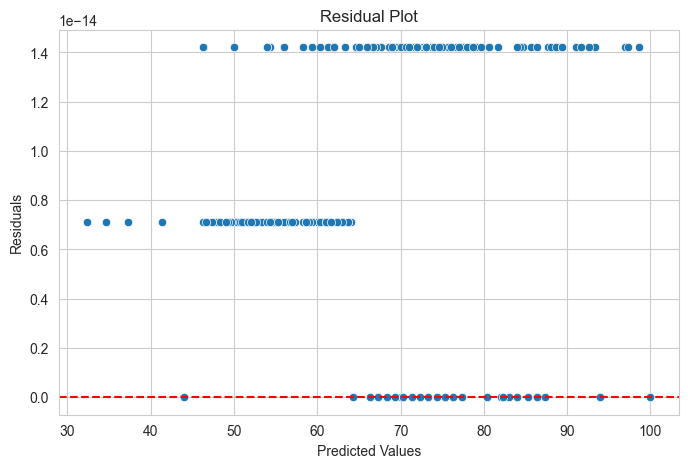

In [187]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_lr, y=residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# Train Modal Using Random Forest


In [188]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

# Prediction Using Random Forest


In [203]:
y_pred_rf = rf.predict(X_test)
y_pred_rf[:20]

array([91.89666667, 99.62888889, 52.71333333, 77.39888889, 49.02222222,
       56.05444444, 95.07333333, 77.12555556, 83.64333333, 59.17666667,
       61.16      , 87.24333333, 65.09555556, 69.09888889, 85.13888889,
       57.89111111, 42.16666667, 73.33888889, 72.95222222, 87.25      ])

In [190]:
actual_predicted_rf = pd.DataFrame(
    {"Actual value": y_test.values, "Predicted value": y_pred_rf}
)
actual_predicted_rf.head(16)

,Actual value,Predicted value
0,94.000000,91.896667
1,100.000000,99.628889
2,50.000000,52.713333
3,77.333333,77.398889
4,49.000000,49.022222
5,56.333333,56.054444
6,97.000000,95.073333
7,77.333333,77.125556
8,83.000000,83.643333
9,59.333333,59.176667


# Evalution Of Random Forest


In [191]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest MSE :", mse_rf)
print("Rondom Forest MAE :", mae_rf)
print("Random Forest RMAE:", rmse_rf)
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest MSE : 0.5128371617408495
Rondom Forest MAE : 0.452962962962963
Random Forest RMAE: 0.7161264984210887
Random Forest R2: 0.9972124351970498


# Actual vs Predicted plot


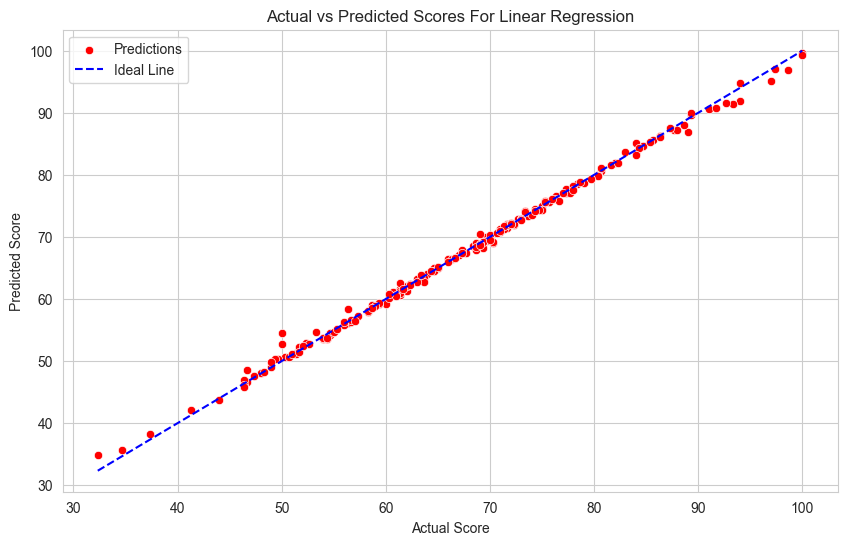

In [192]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=y_pred_rf, color="red", label="Predictions")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="blue",
    linestyle="--",
    label="Ideal Line",
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores For Linear Regression")
plt.legend()

sns.set_style("whitegrid")

plt.show()

In [193]:
rf_ess = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
stack_model = StackingRegressor(
    estimators=[("rf_ess", rf_ess), ("gb", gb)], final_estimator=LinearRegression()
)
stack_model.fit(X_train_scale, y_train)
y_pred_stack = stack_model.predict(X_test_scale)

In [194]:
actual_predicted_stack = pd.DataFrame(
    {"Actual value": y_test.values, "Predicted value": y_pred_stack}
)
actual_predicted_stack.head(15)

,Actual value,Predicted value
0,94.000000,92.582171
1,100.000000,99.785057
2,50.000000,51.852341
3,77.333333,77.131239
4,49.000000,48.644803
5,56.333333,55.862813
6,97.000000,95.931307
7,77.333333,77.283319
8,83.000000,83.081421
9,59.333333,58.907242


In [195]:
mae = mean_absolute_error(y_test, y_pred_stack)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_stack))
msa = mean_squared_error(y_test, y_pred_stack)
print("Stacking MAE:", mae)
print("Stacking RMSE:", rmse)
print("Stacking MSE:", msa)
print("Stacking R2 Score:", r2_score(y_test, y_pred_stack))

Stacking MAE: 0.3942516934781799
Stacking RMSE: 0.5498657215170236
Stacking MSE: 0.30235231169943694
Stacking R2 Score: 0.9983565413642744


# Comparison Of Both Model R2 score


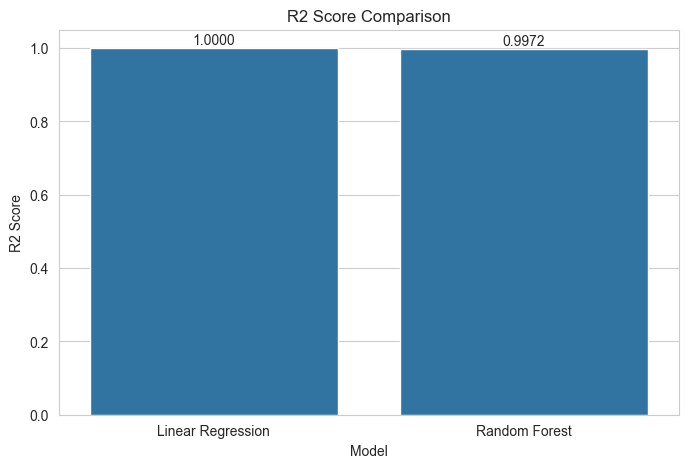

In [196]:
data = {
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf)],
}

df = pd.DataFrame(data)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Model", y="R2 Score")

plt.title("R2 Score Comparison")

for i in range(len(df)):
    plt.text(i, df["R2 Score"][i] + 0.01, f"{df['R2 Score'][i]:.4f}", ha="center")

plt.show()

# GridSearchCV of Linear Model


In [197]:
lr2 = LinearRegression()

param_grid_lr = {"fit_intercept": [True, False], "positive": [True, False]}
grid_lr = GridSearchCV(lr2, param_grid_lr, cv=5)

grid_lr.fit(X_train_scale, y_train)

print("Best parameters:", grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
y_pred_lr2 = best_lr.predict(X_test_scale)
print("MSE:", mean_squared_error(y_test, y_pred_lr2))
print("MAE:", mean_absolute_error(y_test, y_pred_lr2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr2)))
print("R2:", r2_score(y_test, y_pred_lr2))

Best parameters: {'fit_intercept': True, 'positive': True}
MSE: 1.1219355096476613e-28
MAE: 9.043271182401275e-15
RMSE: 1.0592145720521698e-14
R2: 1.0


# RandomizedSearchCV of Linear Model


In [198]:
lr3 = LinearRegression()

param_dist = {
    "fit_intercept": [True, False],
    "copy_X": [True, False],
    "positive": [True, False],
}

random_search = RandomizedSearchCV(
    lr3, param_distributions=param_dist, n_iter=10, cv=5, random_state=42
)

random_search.fit(X_train_scale, y_train)

best_model = random_search.best_estimator_
y_pred_l3 = best_model.predict(X_test_scale)

print("Best Params:", random_search.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred_l3))
print("MAE:", mean_absolute_error(y_test, y_pred_l3))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_l3)))
print("R2:", r2_score(y_test, y_pred_l3))

Best Params: {'positive': True, 'fit_intercept': True, 'copy_X': True}
MSE: 1.1219355096476613e-28
MAE: 9.043271182401275e-15
RMSE: 1.0592145720521698e-14
R2: 1.0


c:\Users\PARMAR ISHIKA\anaconda3\envs\my_environment\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


# GridSearchCV of Random Forest


In [199]:
rf2 = RandomForestRegressor(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

grid_rf = GridSearchCV(
    rf2,
    param_grid=param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_
y_pred_rf2 = best_rf.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred_rf2))
print("MAE:", mean_absolute_error(y_test, y_pred_rf2))
print("R2:", r2_score(y_test, y_pred_rf2))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
MSE: 0.5069000561167238
MAE: 0.44917508417508634
R2: 0.9972447067793452


# RandomizedSerchCV of RandomForest


In [200]:
rf3 = RandomForestRegressor(random_state=42)

param_dist_rf = {
    "n_estimators": np.arange(50, 300),
    "max_depth": [None, 10, 20],
    "min_samples_split": np.arange(2, 10),
    "min_samples_leaf": np.arange(1, 10),
}

random_rf = RandomizedSearchCV(
    rf3,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    random_state=42,
)

random_rf.fit(X_train, y_train)

print("Best Parameters:", random_rf.best_params_)
best_rf = random_rf.best_estimator_
y_pred_rf3 = best_rf.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred_rf3))
print("MAE:", mean_absolute_error(y_test, y_pred_rf3))
print("R2:", r2_score(y_test, y_pred_rf3))

Best Parameters: {'n_estimators': np.int64(233), 'min_samples_split': np.int64(3), 'min_samples_leaf': np.int64(2), 'max_depth': None}
MSE: 0.5867698918703247
MAE: 0.4676088279488169
R2: 0.996810568305042


# Save Model


In [201]:
import joblib

joblib.dump(
    {"lr_model": lr, "rf_model": rf, "columns": X.columns, "scaler": st_x}, "models.pkl"
)

print("Both models Saved Successfully!!")

Both models Saved Successfully!!
